# Feature Scaling

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
ads = pd.read_csv('ads.csv')

In [3]:
ads.head()

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0


# Train test Split

In [5]:
! pip install threadpoolctl

In [4]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(ads.drop('Purchased',axis=1),ads['Purchased'],test_size=0.3,random_state=42)

In [5]:
x_train

,Age,EstimatedSalary
157,29,75000
109,38,80000
17,45,26000
347,54,108000
24,46,23000
...,...,...
71,24,27000
106,26,35000
270,43,133000
348,39,77000


In [6]:
x_test.head()

,Age,EstimatedSalary
209,46,22000
280,59,88000
33,28,44000
210,48,96000
93,29,28000


In [7]:
y_train.head()

157    0
109    0
17     1
347    1
24     1
Name: Purchased, dtype: int64

In [8]:
y_test.head()

209    0
280    1
33     0
210    1
93     0
Name: Purchased, dtype: int64

In [9]:
from sklearn.preprocessing import StandardScaler

In [10]:
scaler = StandardScaler() # creating object 

In [11]:
ads.head()

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0


In [12]:
x_test

,Age,EstimatedSalary
209,46,22000
280,59,88000
33,28,44000
210,48,96000
93,29,28000
...,...,...
60,27,20000
79,26,17000
285,37,93000
305,42,54000


In [13]:
y_train

157    0
109    0
17     1
347    1
24     1
      ..
71     0
106    0
270    0
348    0
102    0
Name: Purchased, Length: 280, dtype: int64

In [14]:
y_test

209    0
280    1
33     0
210    1
93     0
      ..
60     0
79     0
285    1
305    0
281    0
Name: Purchased, Length: 120, dtype: int64

In [15]:
x_train_scaled = scaler.fit_transform(x_train)

In [16]:
x_test_scaled = scaler.fit_transform(x_test)

In [19]:
scaler.mean_

array([3.78416667e+01, 6.77666667e+04])

# conversion of scaled numpy array to dataFrame

In [21]:
x_train_scaled = pd.DataFrame(x_train_scaled,columns=x_train.columns)
x_test_scaled = pd.DataFrame(x_test_scaled,columns=x_test.columns)

In [22]:
x_train_scaled.head()

,Age,EstimatedSalary
0,-0.842522,0.130156
1,0.041758,0.277702
2,0.729530,-1.315791
3,1.613809,1.103957
4,0.827784,-1.404318


In [24]:
x_test_scaled.head()

,Age,EstimatedSalary
0,0.733726,-1.332030
1,1.902890,0.588887
2,-0.885118,-0.691724
3,0.913597,0.821726
4,-0.795182,-1.157401


In [25]:
x_train.head()

,Age,EstimatedSalary
157,29,75000
109,38,80000
17,45,26000
347,54,108000
24,46,23000


In [29]:
np.round(x_train.describe(),1)

,Age,EstimatedSalary
count,280.000,280.000
mean,37.575,70589.286
std,10.196,33948.505
min,18.000,15000.000
25%,30.000,44000.000
50%,37.000,71000.000
75%,45.000,88000.000
max,60.000,150000.000


# Effect of scaling

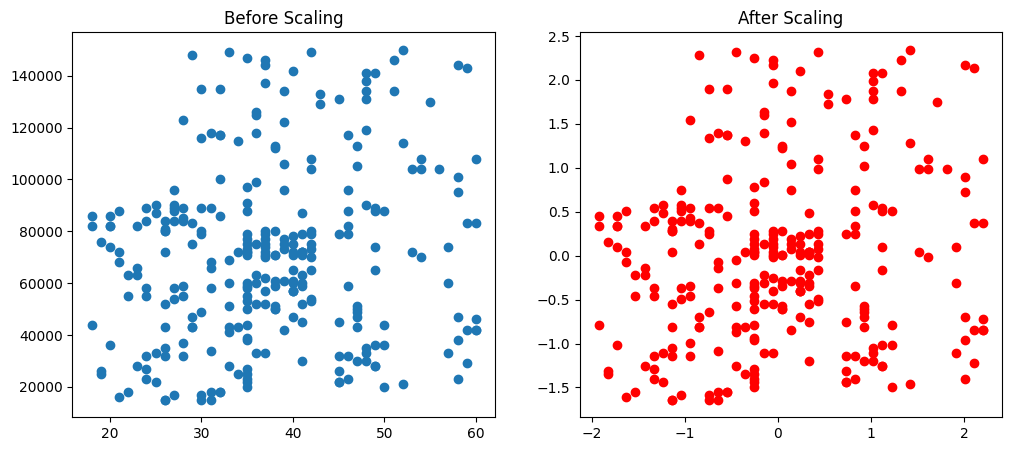

In [31]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

ax1.scatter(x_train['Age'], x_train['EstimatedSalary'])
ax1.set_title("Before Scaling")
ax2.scatter(x_train_scaled['Age'], x_train_scaled['EstimatedSalary'],color='red')
ax2.set_title("After Scaling")
plt.show()

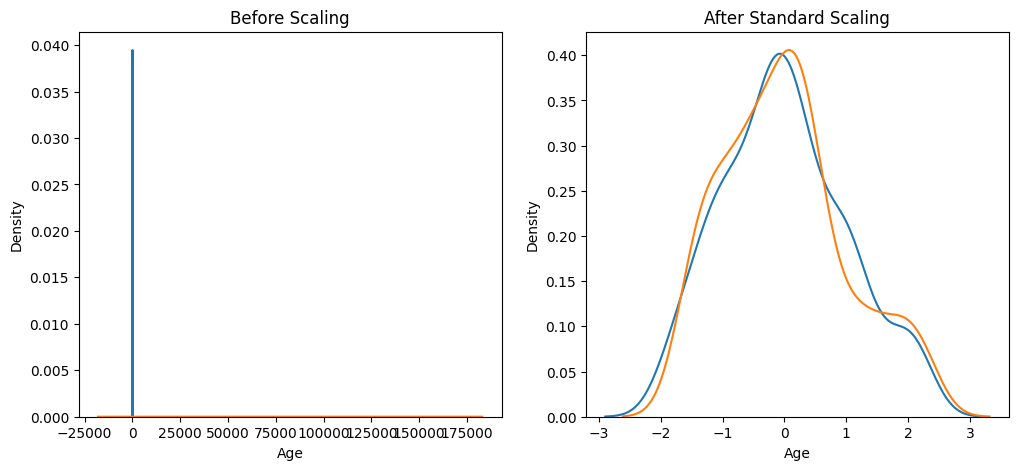

In [32]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# before scaling
ax1.set_title('Before Scaling')
sns.kdeplot(x_train['Age'], ax=ax1)
sns.kdeplot(x_train['EstimatedSalary'], ax=ax1)

# after scaling
ax2.set_title('After Standard Scaling')
sns.kdeplot(x_train_scaled['Age'], ax=ax2)
sns.kdeplot(x_train_scaled['EstimatedSalary'], ax=ax2)
plt.show()

# Comparison of Distributions

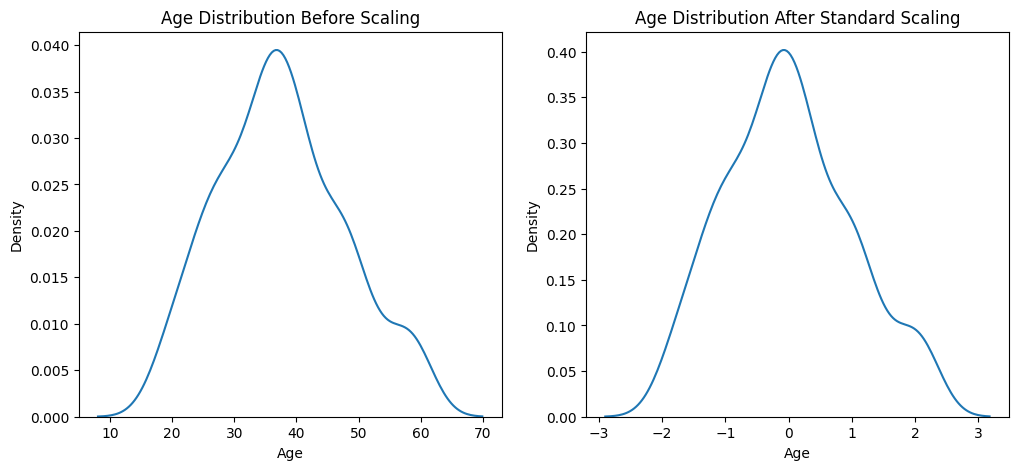

In [33]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# before scaling
ax1.set_title('Age Distribution Before Scaling')
sns.kdeplot(x_train['Age'], ax=ax1)

# after scaling
ax2.set_title('Age Distribution After Standard Scaling')
sns.kdeplot(x_train_scaled['Age'], ax=ax2)
plt.show()

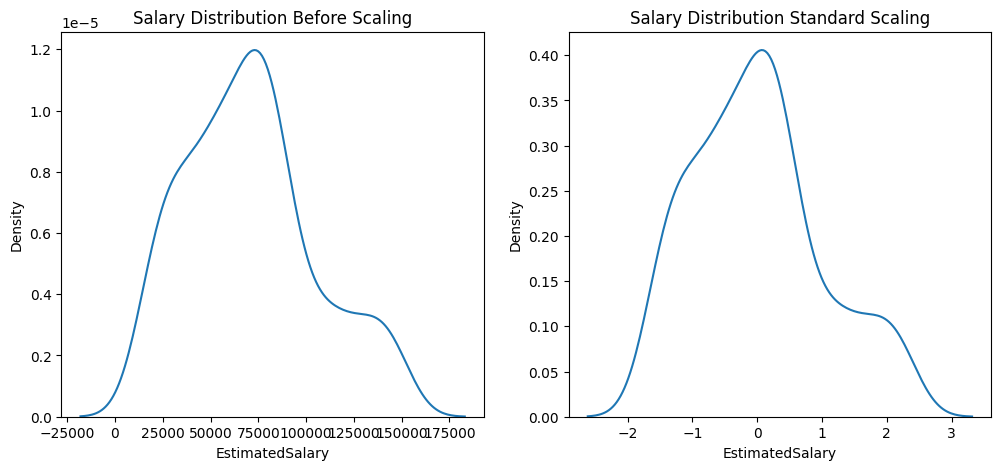

In [34]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# before scaling
ax1.set_title('Salary Distribution Before Scaling')
sns.kdeplot(x_train['EstimatedSalary'], ax=ax1)

# after scaling
ax2.set_title('Salary Distribution Standard Scaling')
sns.kdeplot(x_train_scaled['EstimatedSalary'], ax=ax2)
plt.show()

# Why scaling is important?

In [35]:
from sklearn.linear_model import LogisticRegression

In [36]:

lr = LogisticRegression()
lr_scaled = LogisticRegression()

In [37]:
lr.fit(x_train,y_train)
lr_scaled.fit(x_train_scaled,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [38]:
y_pred = lr.predict(x_test)
y_pred_scaled = lr_scaled.predict(x_test_scaled)

In [39]:
from sklearn.metrics import accuracy_score

In [40]:
print("Actual",accuracy_score(y_test,y_pred))
print("Scaled",accuracy_score(y_test,y_pred_scaled))

Actual 0.85
Scaled 0.85


In [41]:
from sklearn.tree import DecisionTreeClassifier

In [42]:
dt = DecisionTreeClassifier()
dt_scaled = DecisionTreeClassifier()

In [43]:
dt.fit(x_train,y_train)
dt_scaled.fit(x_train_scaled,y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

In [44]:
y_pred = dt.predict(x_test)
y_pred_scaled = dt_scaled.predict(x_test_scaled)

In [45]:
print("Actual",accuracy_score(y_test,y_pred))
print("Scaled",accuracy_score(y_test,y_pred_scaled))

Actual 0.8583333333333333
Scaled 0.8666666666666667


In [49]:
ads = pd.concat(
    [ads,
     pd.DataFrame({
         'Age':[5,90,95],
         'EstimatedSalary':[1000,250000,350000],
         'Purchased':[0,1,1]
     })
    ],
    ignore_index=True
)

In [48]:
ads.head()

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0


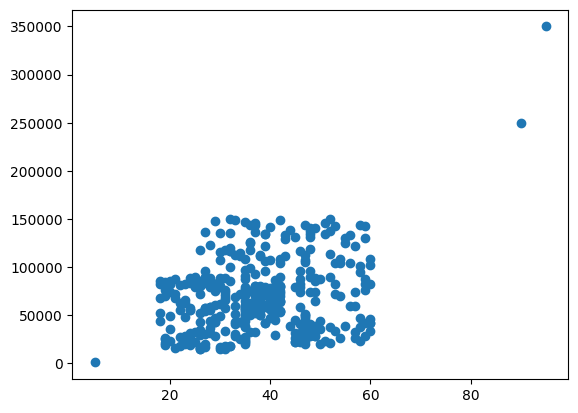

In [50]:
plt.scatter(ads['Age'], ads['EstimatedSalary'])

In [51]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(ads.drop('Purchased', axis=1),
                                                    ads['Purchased'],
                                                    test_size=0.3,
                                                    random_state=0)

x_train.shape, x_test.shape

((282, 2), (121, 2))

In [52]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# fit the scaler to the train set, it will learn the parameters
scaler.fit(x_train)

# transform train and test sets
x_train_scaled = scaler.transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [53]:
x_train_scaled = pd.DataFrame(x_train_scaled, columns=x_train.columns)
x_test_scaled = pd.DataFrame(x_test_scaled, columns=x_test.columns)

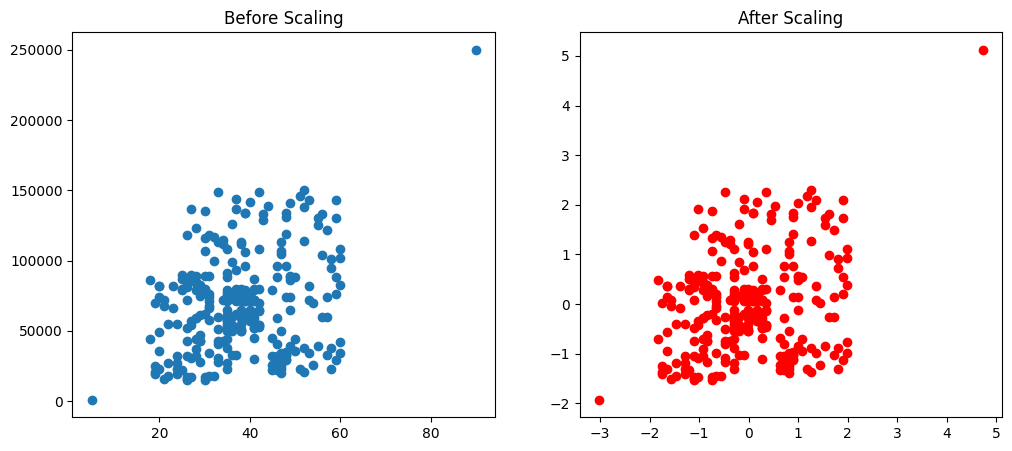

In [54]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

ax1.scatter(x_train['Age'], x_train['EstimatedSalary'])
ax1.set_title("Before Scaling")
ax2.scatter(x_train_scaled['Age'], x_train_scaled['EstimatedSalary'],color='red')
ax2.set_title("After Scaling")
plt.show()

In [55]:
! git status

fatal: not a git repository (or any of the parent directories): .git


In [56]:
! git init


Initialized empty Git repository in C:/Users/dspri/AIML/machine_learning_slot2/.git/


In [57]:
! git status


On branch master

No commits yet

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	.ipynb_checkpoints/
	ads.csv
	day24.ipynb
	day25.ipynb
	day26.ipynb
	day27.ipynb
	day28.ipynb
	day29.ipynb
	day30.ipynb
	day31.ipynb
	day32.ipynb
	day33.ipynb
	day34.ipynb
	day35.ipynb
	day36.ipynb
	day37.ipynb
	day38.ipynb
	day39.ipynb
	day40.ipynb

nothing added to commit but untracked files present (use "git add" to track)


In [58]:
! git add Standarization


fatal: pathspec 'Standarization' did not match any files


In [60]:
! git add Standarization.ipynb


In [61]:
! git status


On branch master

No commits yet

Changes to be committed:
  (use "git rm --cached <file>..." to unstage)
	new file:   Standarization.ipynb

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	.ipynb_checkpoints/
	ads.csv
	day25.ipynb
	day26.ipynb
	day27.ipynb
	day28.ipynb
	day29.ipynb
	day30.ipynb
	day31.ipynb
	day32.ipynb
	day33.ipynb
	day34.ipynb
	day35.ipynb
	day36.ipynb
	day37.ipynb
	day38.ipynb
	day39.ipynb
	day40.ipynb



In [62]:
! git commit -m "Applying Satndarization on ads dataset"

[master (root-commit) 447ccde] Applying Satndarization on ads dataset
 1 file changed, 3438 insertions(+)
 create mode 100644 Standarization.ipynb


In [63]:
! git branch

* master


In [64]:
! git branch - M main

usage: git branch [<options>] [-r | -a] [--merged] [--no-merged]
   or: git branch [<options>] [-f] [--recurse-submodules] <branch-name> [<start-point>]
   or: git branch [<options>] [-l] [<pattern>...]
   or: git branch [<options>] [-r] (-d | -D) <branch-name>...
   or: git branch [<options>] (-m | -M) [<old-branch>] <new-branch>
   or: git branch [<options>] (-c | -C) [<old-branch>] <new-branch>
   or: git branch [<options>] [-r | -a] [--points-at]
   or: git branch [<options>] [-r | -a] [--format]

Generic options
    -v, --[no-]verbose    show hash and subject, give twice for upstream branch
    -q, --[no-]quiet      suppress informational messages
    -t, --[no-]track[=(direct|inherit)]
                          set branch tracking configuration
    -u, --[no-]set-upstream-to <upstream>
                          change the upstream info
    --[no-]unset-upstream unset the upstream info
    --[no-]color[=<when>] use colored output
    -r, --remotes         act on remote-tracking br

In [65]:
! git branch

* master


In [66]:
! git branch - M main

usage: git branch [<options>] [-r | -a] [--merged] [--no-merged]
   or: git branch [<options>] [-f] [--recurse-submodules] <branch-name> [<start-point>]
   or: git branch [<options>] [-l] [<pattern>...]
   or: git branch [<options>] [-r] (-d | -D) <branch-name>...
   or: git branch [<options>] (-m | -M) [<old-branch>] <new-branch>
   or: git branch [<options>] (-c | -C) [<old-branch>] <new-branch>
   or: git branch [<options>] [-r | -a] [--points-at]
   or: git branch [<options>] [-r | -a] [--format]

Generic options
    -v, --[no-]verbose    show hash and subject, give twice for upstream branch
    -q, --[no-]quiet      suppress informational messages
    -t, --[no-]track[=(direct|inherit)]
                          set branch tracking configuration
    -u, --[no-]set-upstream-to <upstream>
                          change the upstream info
    --[no-]unset-upstream unset the upstream info
    --[no-]color[=<when>] use colored output
    -r, --remotes         act on remote-tracking br

In [67]:
! git branch

* master


In [68]:
! git branch -M main

In [69]:
! git branch

* main


In [70]:
! git push origin main

fatal: 'origin' does not appear to be a git repository
fatal: Could not read from remote repository.

Please make sure you have the correct access rights
and the repository exists.
